#### Importación de librerías necesarias

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones

from IPython.display import display

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import hashlib

#### Carga de Data

In [2]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")

#### Información inicial de Data

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

# Manipulación de Datos

In [6]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [7]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [8]:
# convertir SeniorCitizen a object para que sea categórico
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: '0', 1: '1'}).astype(object)
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [9]:
# información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

* La variable objetivo que guiará nuestra exploración es el **Churn**.

#### Implementación de Anonimización

* De acuerdo con la legislación sobre protección de la vida privada, almacenar de forma directa el ID del cliente (CustomerID) junto con su comportamiento financiero expone a la empresa a severas multas.

In [10]:
def anonimizar(texto):
    # Genera un Hash único para el nombre (Irreversible)
    return hashlib.sha256(texto.encode()).hexdigest()

# Aplicar a la columna sensible
df['customerID_Hash'] = df['customerID'].apply(anonimizar)

# Eliminar el dato original
df.drop('customerID', axis=1, inplace=True)

In [11]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,f3f9002e121cbbcc038f195a656a32a17395c6ce1815e8...
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5f362546eb7515f442a40d3d9bf632e4a481c92bcb0529...
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,701bf78bdf332d16ec5fb80a1affac3a080a8b9c258c2d...
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,59a0e1b332a6b6ba8f6a72f74085e6498e8c54a5d18191...
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,66370db9e1bb6a851fa692a2499f4f1356efab8e5abf90...


# Análisis Exploratorio de Datos

#### Análisis de completitud

In [12]:
# conteo de valores nulos por columna
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
customerID_Hash      0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [13]:
# muestra registros con valores nulos en TotalCharges
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,3fc827a9c771a5597e1b9563ba46bd77b5a33daad5f094...
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,cc8dcc067e61d7292f35e1d99cf280c8f1663b1d6b9dc0...
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,58d283200bed248b5d1e0eb621b905ecbb502854900fb3...
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,ea0b24cc08647ff604fd33a68453a8adb51fdc83f96386...
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0e9341d2f088bdb7928f46db857c21c35c9eaafb56084d...
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,8c6c0d363aa75ea0795734b32d5adcbbd77845674cc04e...
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,f3d447e5d65b5d31443dae3b897268f29b906c53a3bb29...
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,3c63ffbaff09f452804dc16726922dfddfb6354320fd79...
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,01b32519075edcfd0f091c271f6cc693e2ed154b5a38c9...
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,53819de429be29e2cf2d830bf81fd95987cea3db3612ce...


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [14]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


#### Análisis de valores duplicados

In [15]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

#### Análisis de valores atípicos

In [16]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


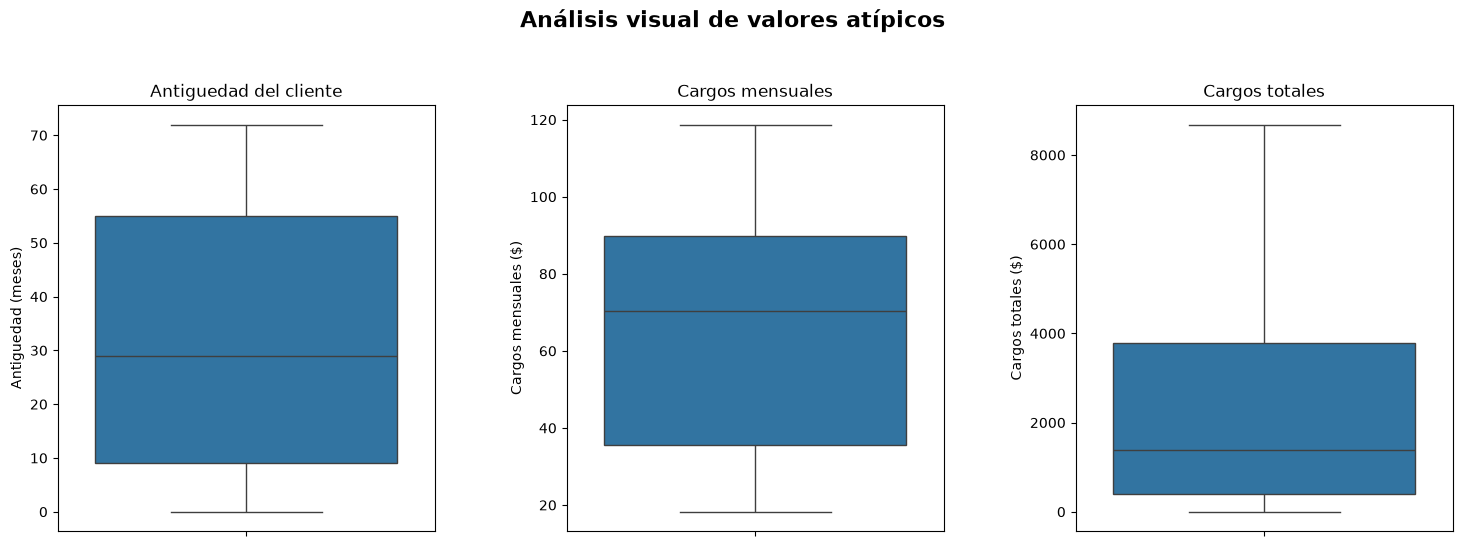

In [17]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antiguedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

#### Estadísticas básicas

In [ ]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID_Hash", axis=0)

KeyError: "['customerID'] not found in axis"

Hallazgos relevantes:

* La distribución por género es equilibrada: hay 3555 hombres y 3488 mujeres
* La clase positiva **Churn = Yes**, que representa a los clientes que sí abandonan el servicio, contiene 1869 registros (26,5%)
* La mayoría de los clientes no son adultos mayores: **SeniorCitizen** = 0 representa aproximadamente el 83,8%
* El contrato más frecuente es mensual, con 3875 clientes, lo que representa aproximadamente el 55%
* Cerca del 90,3% de los clientes tiene servicio telefónico

In [ ]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

## Análisis Descriptivo

#### Variable Objetivo

In [ ]:
fig, ax = visualizaciones.graficar_distribucion_churn(
    df,
    ruta_salida="../resultados/plots/distribucion_variable_objetivo.png"
)
plt.show()

* La tasa general de churn es del 26.5%. Veamos entonces los distintos grupos de clientes. ¿Qué grupos presentan una mayor probabilidad de abandono?

### Características Numéricas

Para las variables numéricas, se calculan y grafican las funciones de estimación de densidad de kernel (KDE).

In [ ]:
# generar curvas de densidad según la variable Churn
fig, axes = visualizaciones.graficar_curvas_densidad_churn(
    df,
    ruta_salida="../resultados/plots/curvas_densidad_churn.png"
)
plt.show()

In [ ]:
# mapa de calor matriz de correlaciones variables numéricas
df_copy = df.copy()
df_copy["Churn"] = df_copy["Churn"].map({"No": 0, "Yes": 1}).astype(object)
df_copy["Churn"] = pd.to_numeric(df_copy["Churn"], errors="coerce")
numeric_df = df_copy.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=['customerID_Hash'], errors='ignore')
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Telco Customer Churn')
plt.show()

* Antiguedad y Cargos Totales (0,825): Fuerte correlación positiva. Como es lógico, los clientes que llevan más tiempo en la empresa acumulan un gasto total mayor.

* Antiguedad y Cargos Mensuales (0,248): Correlación positiva débil. Existe una ligera tendencia donde los clientes más antiguos asumen tarifas mensuales un poco más altas, lo que sugiere que podrían estar contratando servicios de mayor precio.

In [ ]:
# agrupar por 'Churn' y calcular el promedio
resumen = df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
tabla_churn_numeric = resumen.T
tabla_churn_numeric.columns = ['Churn = No', 'Churn = Sí']
tabla_churn_numeric

Se pueden extraer las siguientes conclusiones:

**Antiguedad (Meses):**

* Los clientes activos tienen una antiguedad promedio de 37,57 meses.
* Quienes cancelaron el servicio muestran una permanencia menor, con un promedio de 17,98 meses.
* A mayor tiempo en la compañía, menor es la probabilidad de abandono.
* Los clientes nuevos con poca antiguedad tienen más probabilidades de cambiar de compañía.

**Cargos Mensuales:**

* El pago mensual promedio de los clientes activos es de $61,27.
* Quienes se dieron de baja pagaban una tarifa un poco mayor, cercana a los $74,44.
* Los clientes que pagan cargos mensuales más altos también tienen más probabilidades de cancelar el servicio.

**Cargos Totales:**

* Los clientes que mantienen su suscripción acumulan un promedio de $2554,77 en cargos totales.
* Quienes cancelaron el servicio acumularon un gasto inferior, de alrededor de $1531,80.
* Los usuarios con un mayor gasto total acumulado en el tiempo son más propensos a quedarse en la empresa.

### Variables Categóricas

Para las variables categóricas, los gráficos de barras muestran las diferencias entre los grupos objetivo.

#### Información de Clientes

In [ ]:
figura_cliente = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información del cliente",
    ruta_salida="../resultados/plots"
)
display(figura_cliente)
plt.close(figura_cliente)

* La cantidad de cancelaciones es muy similar entre clientes hombres y mujeres, sin presentar una diferencia importante.
* Clientes sin pareja y clientes sin familiares (dependientes), así como los adultos mayores en proporción tiene mayor probabilidad de abono.
* La mayor parte de los clientes que son adultos mayores termina cancelando su servicio.

#### Servicios Contratados

In [ ]:
figura_servicios = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Servicios contratados",
    ruta_salida="../resultados/plots"
)
display(figura_servicios)
plt.close(figura_servicios)

* Un alto número de clientes con internet de fibra óptica cancelaron su servicio.
* Los usuarios con conexión DSL abandonan la compañía con menor frecuencia.
* Los clientes que no cuentan con servicio de internet presentan una tasa de abandono muy baja.
* Una gran parte de los clientes elige el servicio de fibra óptica, pero presentan una alta tasa de abandono, lo que sugiere una posible insatisfacción con este tipo de conexión.

#### Seguridad y soporte

In [ ]:
figura_seguridad = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Seguridad y soporte",
    ruta_salida="../resultados/plots"
)
display(figura_seguridad)
plt.close(figura_seguridad)

* Seguridad en línea y Soporte técnico son los servicios que más protegen la retención, bajando el abandono de un 42% (clientes sin el servicio) a solo un 15% (clientes con el servicio).
* Respaldo y Protección del dispositivo también muestran un impacto positivo logrando reducir el nivel de fuga de un 40% a un 22%.
* Los clientes que contrataron servicios de seguridad o soporte técnico adicional tienen menos probabilidades de cancelar su servicio. Resulta clave ofrecer promociones que incluyan seguridad o soporte técnico.

#### Información de Pago

In [ ]:
figura_pago = visualizaciones.graficar_grupo_categorico_churn(
    df,
    nombre_grupo="Información de pago",
    ruta_salida="../resultados/plots"
)
display(figura_pago)
plt.close(figura_pago)

* El abandono es crítico en la modalidad "Mes a mes" (42.7%), pero disminuye drásticamente en compromisos de "Un año" (11.2%) y "Dos años" (2.8%).
* Los clientes con facturación electrónica presentan el doble de tasa de abandono (33.5%) que aquellos con facturación tradicional (16.3%).
* El "Cheque electrónico" es el método de mayor riesgo con un 45.2% de fuga, mientras que las otras alternativas promedian un abandono mucho menor (15-19%).


* Es prioritario incentivar contratos largos. Ofrecer beneficios para que los clientes mensuales pasen a planes anuales o de dos años, donde la tasa de abandono es casi nula.
* Se sugiere revisar el cheque electrónico. Es importante investigar por qué este método genera tantas cancelaciones y sugerir activamente a los clientes que cambien al pago automático.
* Se debe fidelizar al cliente digital. Ya que la facturación electrónica facilita la cancelación, necesitamos buscar nuevas formas de recordarles el valor del servicio para que decidan quedarse.



# Limpieza y Transformación de Datos

In [ ]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(object)
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")

* Manipulamos el formato de los valores de la variable objetivo para que el modelo interprete de mejor manera. YES/NO -> 1/0

### Pipelines


In [ ]:
pipeline_numeric = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="uniform")),
    ('scaler', StandardScaler())
])
pipeline_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
pipeline_preprocessor = ColumnTransformer([
    ("numeric", pipeline_numeric, df.select_dtypes(include=['int64', 'float64']).columns.drop(["Churn"])),
    ("categorical", pipeline_categorical, df.select_dtypes(include=['object']).columns.drop(['customerID_Hash']))
])

* Para las variables numericas utilizamos KNN ya que hay pocos registros con nulos y la existencia de correlacion entre las variables que pueden justificar su valor. StandardScaler para estandarizar la variables porque tienen magnitudes diferentes.

* Para las variables categoricas utilizamos SimpleImputer (a pesar de no haber nulos en categoricas) a pesar del riesgo de inflar o desproporcionar las distribuciones. OneHotEncoder ya que la variables cat. son nominales por tanto no tienen un orden jerarquico.

* Descartamos del preprocesador las variables Churn y customerID, porque no aportan al modelo y que churn es el objetivo y customerID es un identificador personal por registro.

In [ ]:
X_crudo = df.drop(['Churn', 'customerID'], axis=1) 
matriz_limpia = pipeline_preprocessor.fit_transform(X_crudo)

if hasattr(matriz_limpia, "toarray"):
    matriz_limpia = matriz_limpia.toarray()

df_limpia = pd.DataFrame(
    matriz_limpia,
    columns=pipeline_preprocessor.get_feature_names_out()
)
df_limpia['Churn'] = df['Churn'].values
df_limpia.head()

In [ ]:
df_limpia.to_csv('../data/Telco_Customer_Churn_limpio.csv', index = False, encoding = "utf-8")

In [ ]:
df_limpia.info()